In [1]:
import sys

sys.path.append("..")

import torch
import matplotlib.pyplot as plt
import numpy as np

from src.paths import Paths
from src.utils import (
    get_device,
    tensor_to_img,
    plot_image,
    initialize_resnet18,
    load_model_weights,
)
from src.data_manager import DataManager
from src.perturbations import Perturbations
from src import config
from src.explainers import IGExplainer, OcclusionExplainer
from src.xai_experiment import XAIExperiment

## Konfiguracja ogólna

In [2]:
dataset_name = "mnist"
epsilon = 0.5


device = get_device()
empty_model = initialize_resnet18(pretrained=False)

paths = Paths()

model = load_model_weights(empty_model, paths.MNIST_MODEL, device)

data_manager = DataManager(paths.DATA_DIR)

test_data = data_manager.get_test_dataset(dataset_name=dataset_name, download=False)
class_names = data_manager.get_class_names(dataset_name=dataset_name)

perturbations = Perturbations(model=model, device=device)

clean_examples = {}
for image, label in test_data:
    if label in clean_examples:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    if pred == label:
        clean_examples[label] = image

    if len(clean_examples) == len(class_names):
        break


## Konfiguracja IG

In [3]:
ig_explainer = IGExplainer(model=model, device=device, config=config.IGConfig())
ig_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=ig_explainer,
    perturbations=perturbations,
)

ig_classes = ig_experiment.selected_classes

all_ig_attrs = []
for class_id in ig_classes:
    clean_tensor = ig_experiment.get_clean_tensor(class_id)
    noised_tensor = ig_experiment.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="fgsm",
        value=epsilon,
    )

    clean_attr = ig_experiment.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["abs"]

    noised_attr = ig_experiment.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["abs"]

    all_ig_attrs.append(clean_attr)
    all_ig_attrs.append(noised_attr)

ig_vmin = 0
ig_vmax = np.percentile([attr.flatten() for attr in all_ig_attrs], 99)


## Czyste obrazy

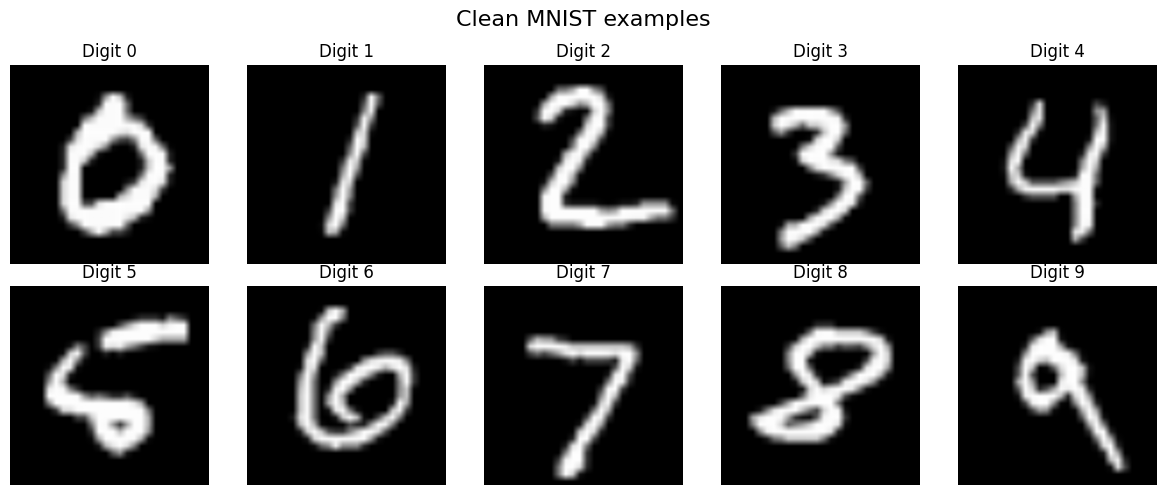

In [4]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5),
)

fig.suptitle("Clean MNIST examples", fontsize=16)

for idx, class_id in enumerate(ig_classes):
    row, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id, to_device=False)

    plot_image(
        axes[row, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {ig_experiment.class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG dla niezaatakowanych danych

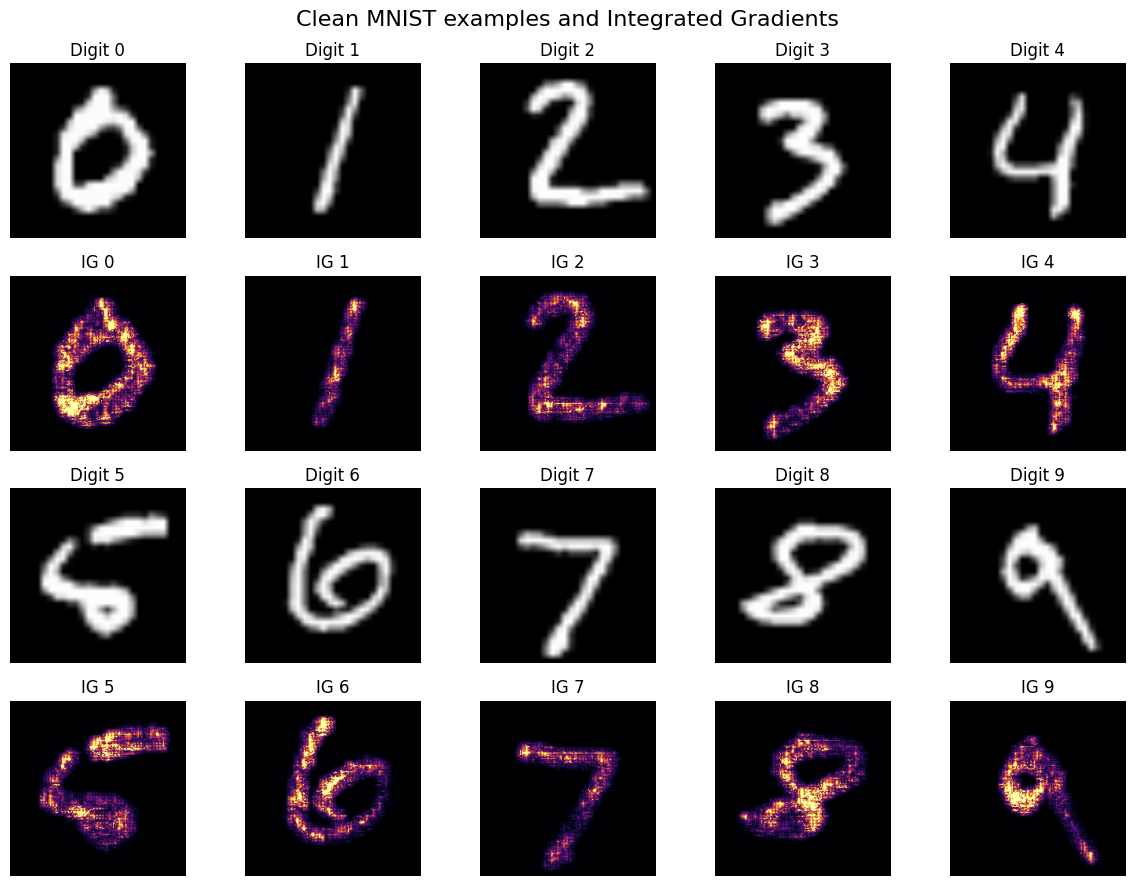

In [5]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "Clean MNIST examples and Integrated Gradients",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id)
    clean_img = tensor_to_img(clean_tensor)

    attr_ig = ig_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_img,
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_ig,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## FGSM - prezentacja

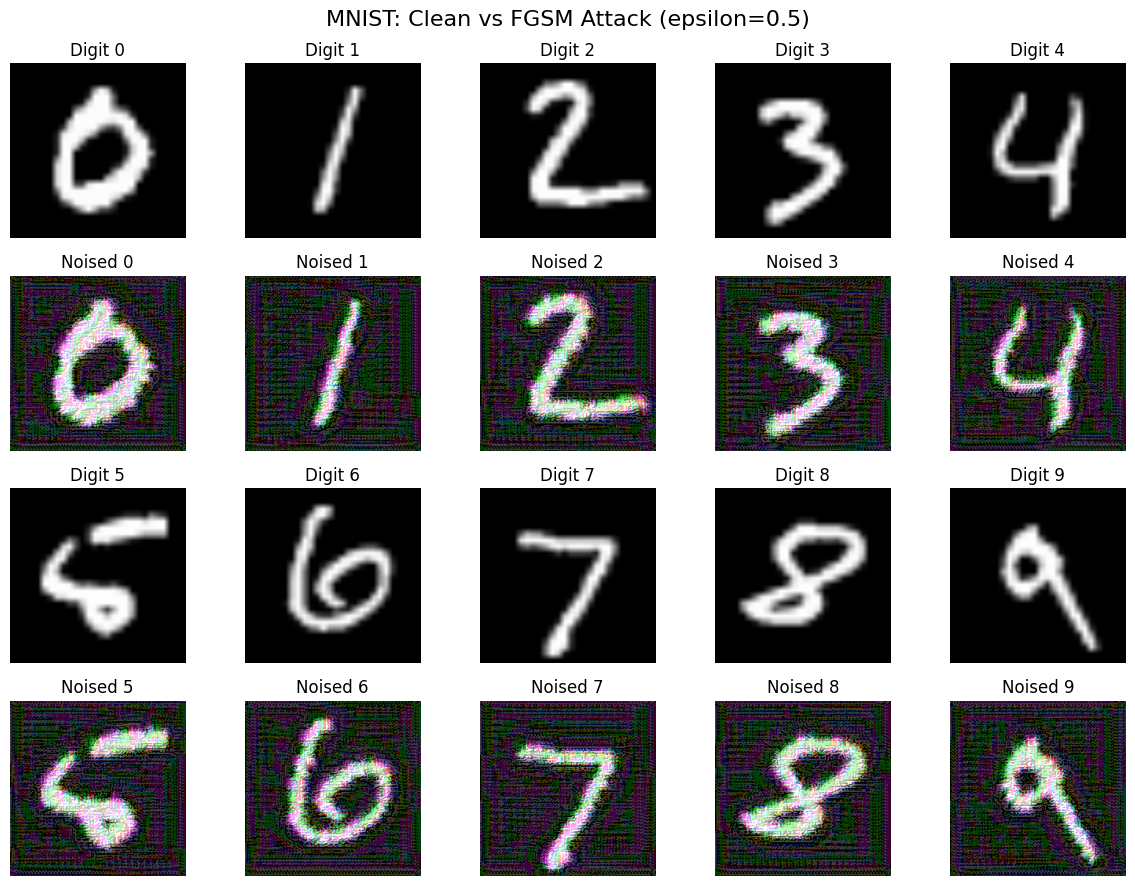

In [ ]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(
        class_id,
        to_device=False,
    )

    noised_tensor = perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        tensor_to_img(noised_tensor),
        title=f"Attacked {class_names[class_id]}",
        cmap="gray",
    )

plt.tight_layout()
plt.show()

## IG przykładów niezaatakowanych oraz zaatakowanych

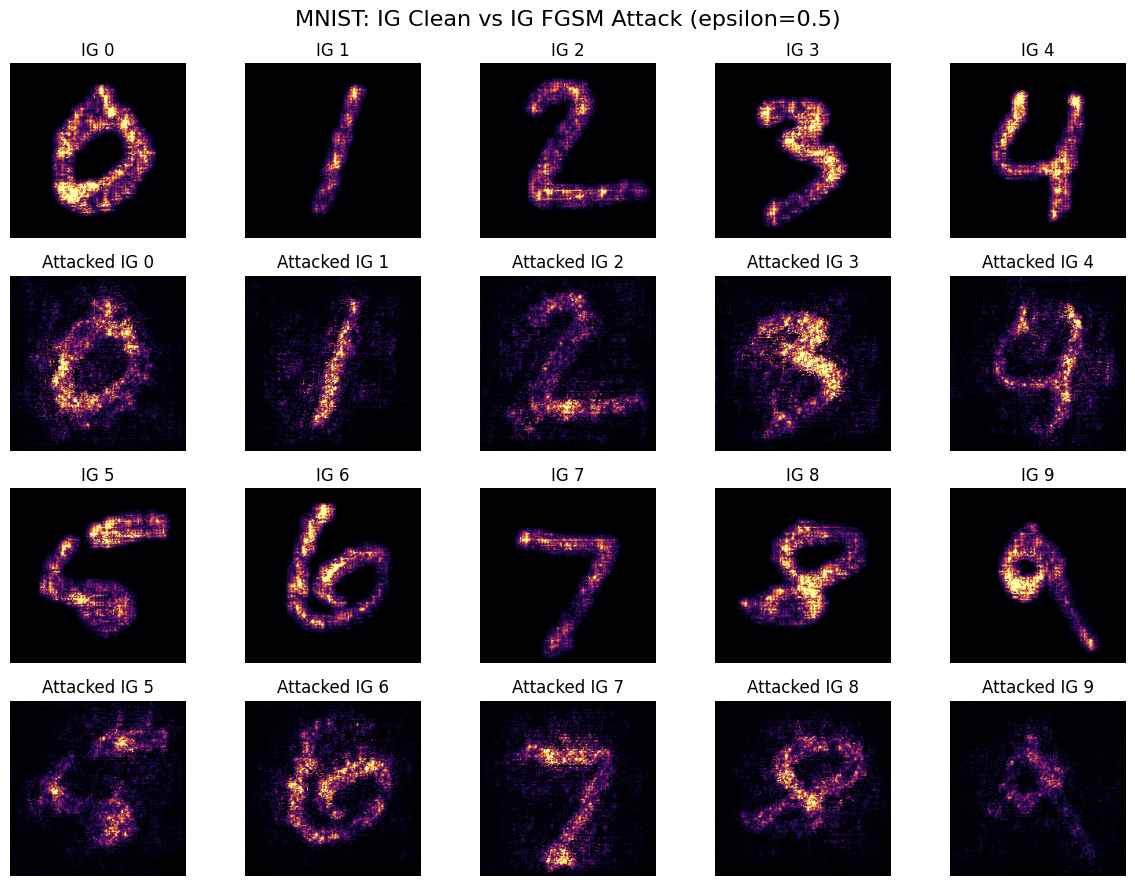

In [7]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: IG Clean vs IG FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(ig_classes):
    block, col = divmod(idx, 5)

    clean_tensor = ig_experiment.get_clean_tensor(class_id)

    noised_tensor = ig_experiment.perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    clean_attr = ig_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    noised_attr = ig_experiment.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        clean_attr,
        title=f"IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        noised_attr,
        title=f"Attacked IG {class_names[class_id]}",
        cmap="inferno",
        vmin=ig_vmin,
        vmax=ig_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU

In [8]:
df_similarity = ig_experiment.run_similarity_metrics(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    ig_experiment.make_pivot(
        df_similarity,
        "TopK_IoU",
    ).round(3)
)

display(ig_experiment.summarize_similarity(df_similarity).round(3))

Processing fgsm=0.01
Processing fgsm=0.05
Processing fgsm=0.1
Processing fgsm=0.2
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.899,0.947,0.884,0.909,0.926,0.896,0.902,0.900,0.901,0.908
0.05,0.822,0.849,0.816,0.820,0.848,0.790,0.816,0.806,0.811,0.786
0.10,0.790,0.790,0.778,0.766,0.798,0.732,0.764,0.762,0.769,0.735
0.20,0.759,0.705,0.726,0.705,0.697,0.643,0.691,0.709,0.746,0.729
0.50,0.620,0.604,0.614,0.636,0.557,0.501,0.555,0.562,0.661,0.461


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.635,0.953,0.664,0.759,0.772,0.652,0.731,0.773,0.718,0.789
0.05,0.519,0.874,0.555,0.640,0.681,0.521,0.600,0.689,0.604,0.699
0.10,0.477,0.787,0.514,0.600,0.642,0.478,0.548,0.656,0.556,0.669
0.20,0.443,0.675,0.476,0.543,0.552,0.434,0.487,0.605,0.516,0.615
0.50,0.333,0.503,0.352,0.461,0.393,0.304,0.360,0.432,0.393,0.425


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.01,0.907,0.018,0.745,0.091
1,0.05,0.816,0.021,0.638,0.106
2,0.10,0.768,0.022,0.593,0.098
3,0.20,0.711,0.032,0.535,0.079
4,0.50,0.577,0.062,0.396,0.061


## Deletion AUC

In [9]:
df_deletion = ig_experiment.run_deletion_auc(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    ig_experiment.make_pivot(
        df_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(ig_experiment.summarize_deletion(df_deletion).round(3))

Processing fgsm=0.01
Processing fgsm=0.05
Processing fgsm=0.1
Processing fgsm=0.2
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.714,0.982,0.505,0.388,0.535,0.247,0.154,0.909,0.649,0.434
0.05,0.492,0.945,0.311,0.279,0.298,0.115,0.049,0.898,0.509,0.130
0.10,0.237,0.706,0.147,0.115,0.154,0.079,0.032,0.798,0.277,0.091
0.20,0.114,0.410,0.101,0.031,0.070,0.020,0.029,0.391,0.082,0.040
0.50,0.055,0.140,0.071,0.007,0.005,0.016,0.012,0.132,0.038,0.012


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.343,0.261,0.552,0.267,0.999,0.997,0
1,0.05,0.343,0.261,0.403,0.312,0.999,0.981,0
2,0.10,0.343,0.261,0.264,0.268,0.999,0.936,0
3,0.20,0.343,0.261,0.129,0.147,0.999,0.812,1
4,0.50,0.343,0.261,0.049,0.051,0.999,0.163,9


## Konfiguracja Occlusion

In [10]:
occ_explainer = OcclusionExplainer(
    model=model, device=device, config=config.OcclusionConfig()
)
occ_experiment = XAIExperiment(
    model=model,
    device=device,
    class_names=class_names,
    clean_examples=clean_examples,
    explainer=occ_explainer,
    perturbations=perturbations,
)

occ_classes = occ_experiment.selected_classes

all_occ_attrs = []
for class_id in occ_classes:
    clean_tensor = occ_experiment.get_clean_tensor(class_id)
    noised_tensor = occ_experiment.get_perturbed_tensor(
        clean_tensor=clean_tensor,
        class_id=class_id,
        perturbation_type="gaussian",
        value=epsilon,
    )

    clean_attr = occ_experiment.explainer.explain(
        input_tensor=clean_tensor, target_class=class_id
    )["raw"]

    noised_attr = occ_experiment.explainer.explain(
        input_tensor=noised_tensor, target_class=class_id
    )["raw"]

    all_occ_attrs.append(clean_attr)
    all_occ_attrs.append(noised_attr)

occ_vmin = min(attr.min() for attr in all_occ_attrs)
occ_vmax = max(attr.max() for attr in all_occ_attrs)


## Occlusion dla niezatakowanych danych

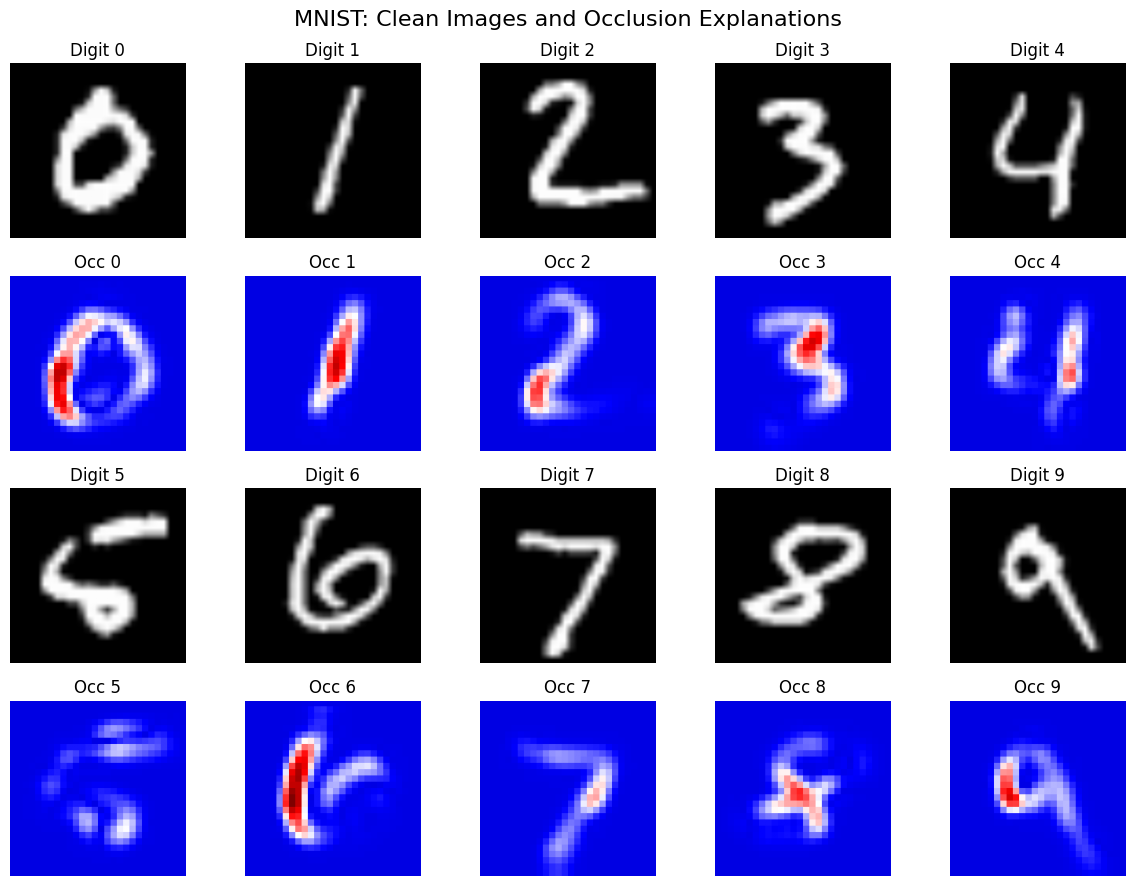

In [11]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    "MNIST: Clean Images and Occlusion Explanations",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment.get_clean_tensor(class_id)

    attr_occ = occ_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["abs"]

    plot_image(
        axes[block * 2, col],
        tensor_to_img(clean_tensor),
        title=f"Digit {occ_experiment.class_names[class_id]}",
        cmap="gray",
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ,
        title=f"Occ {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Occlusion danych niezaatakowanych oraz zaatakowanych

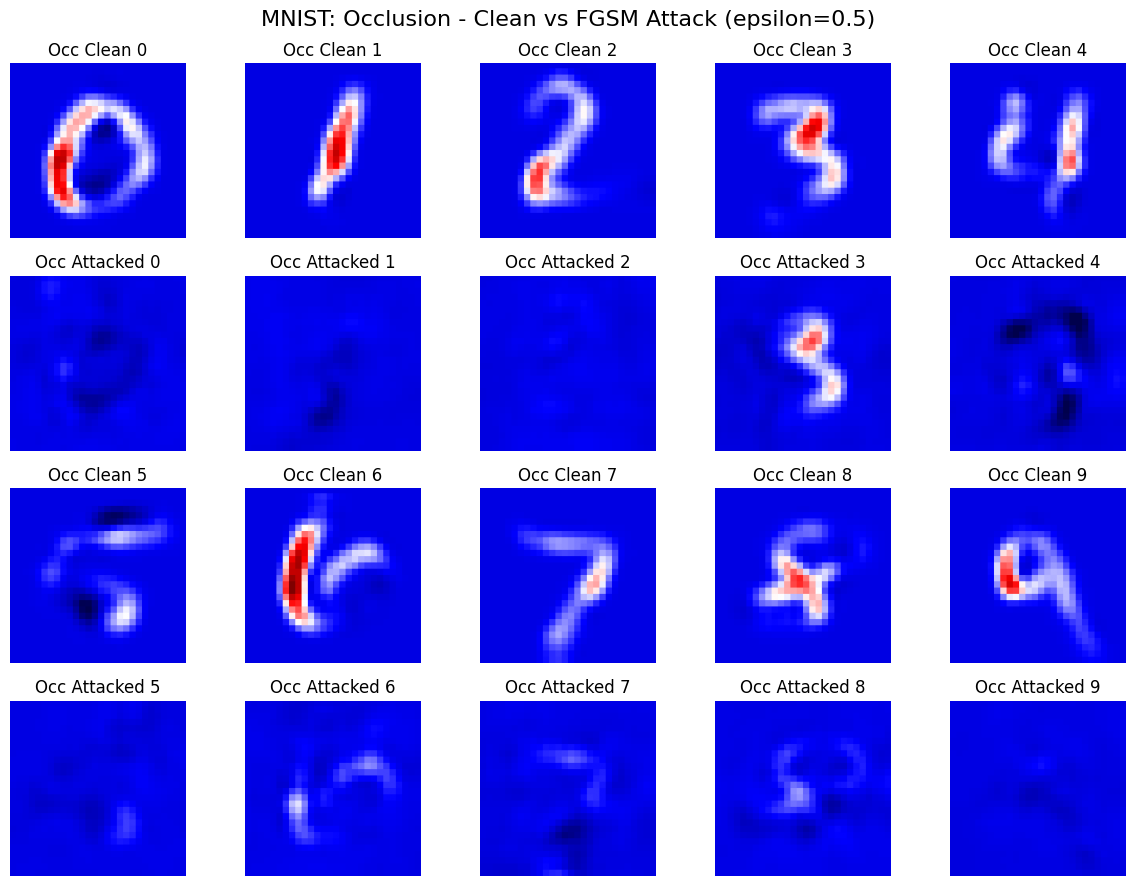

In [13]:
fig, axes = plt.subplots(
    4,
    5,
    figsize=(12, 9),
)

fig.suptitle(
    f"MNIST: Occlusion - Clean vs FGSM Attack (epsilon={epsilon})",
    fontsize=16,
)

for idx, class_id in enumerate(occ_classes):
    block, col = divmod(idx, 5)

    clean_tensor = occ_experiment.get_clean_tensor(class_id)

    noised_tensor = occ_experiment.perturbations.fgsm(
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    attr_occ_clean = occ_experiment.explainer.explain(
        input_tensor=clean_tensor,
        target_class=class_id,
    )["raw"]

    attr_occ_noised = occ_experiment.explainer.explain(
        input_tensor=noised_tensor,
        target_class=class_id,
    )["raw"]

    plot_image(
        axes[block * 2, col],
        attr_occ_clean,
        title=f"Occ Clean {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

    plot_image(
        axes[block * 2 + 1, col],
        attr_occ_noised,
        title=f"Occ Attacked {occ_experiment.class_names[class_id]}",
        cmap="seismic",
        vmin=occ_vmin,
        vmax=occ_vmax,
    )

plt.tight_layout()
plt.show()

## Cosine Similarity oraz TopK IoU (Occlusion)

In [14]:
df_occ_similarity = occ_experiment.run_similarity_metrics(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "CosineSimilarity",
    ).round(3)
)

display(
    occ_experiment.make_pivot(
        df_occ_similarity,
        "TopK_IoU",
    ).round(3)
)

display(occ_experiment.summarize_similarity(df_occ_similarity).round(3))

Processing fgsm=0.01
Processing fgsm=0.05
Processing fgsm=0.1
Processing fgsm=0.2
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,1.000,1.000,1.000,1.000,0.999,0.997,1.000,0.999,1.000,1.000
0.05,0.997,0.993,0.999,0.999,0.966,0.978,0.997,0.991,0.996,0.995
0.10,0.988,0.972,0.996,0.997,0.870,0.956,0.991,0.970,0.989,0.981
0.20,0.925,0.718,0.967,0.985,0.674,0.896,0.968,0.870,0.968,0.887
0.50,0.462,0.483,0.566,0.946,0.558,0.783,0.722,0.744,0.799,0.596


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.975,0.990,0.985,0.985,0.950,0.926,0.996,0.926,0.969,0.975
0.05,0.917,0.950,0.960,0.960,0.828,0.774,0.960,0.880,0.903,0.950
0.10,0.828,0.871,0.912,0.960,0.556,0.742,0.889,0.679,0.815,0.866
0.20,0.584,0.468,0.716,0.844,0.227,0.584,0.794,0.474,0.734,0.610
0.50,0.075,0.403,0.227,0.734,0.193,0.354,0.395,0.415,0.378,0.302


,Value,CosineMean,CosineStd,TopKIoUMean,TopKIoUStd
0,0.01,0.999,0.001,0.968,0.025
1,0.05,0.991,0.011,0.908,0.064
2,0.10,0.971,0.038,0.812,0.121
3,0.20,0.886,0.108,0.603,0.183
4,0.50,0.666,0.157,0.348,0.175


## Deletion AUC (Occlusion)

In [15]:
df_occ_deletion = occ_experiment.run_deletion_auc(
    perturbation_type="fgsm",
    values=config.ExperimentConfig().fgsm_epsilons,
)

display(
    occ_experiment.make_pivot(
        df_occ_deletion,
        "DeletionAUC_Perturbed",
    ).round(3)
)

display(occ_experiment.summarize_deletion(df_occ_deletion).round(3))

Processing fgsm=0.01
Processing fgsm=0.05
Processing fgsm=0.1
Processing fgsm=0.2
Processing fgsm=0.5


ClassName,0,1,2,3,4,5,6,7,8,9
Value,,,,,,,,,,
0.01,0.144,0.992,0.074,0.103,0.103,0.379,0.082,0.148,0.109,0.058
0.05,0.085,0.987,0.063,0.092,0.072,0.380,0.056,0.123,0.121,0.035
0.10,0.083,0.971,0.036,0.080,0.075,0.168,0.046,0.073,0.098,0.027
0.20,0.052,0.705,0.029,0.051,0.071,0.085,0.066,0.056,0.068,0.024
0.50,0.127,0.158,0.013,0.006,0.010,0.208,0.018,0.017,0.036,0.017


,Value,CleanAUCMean,CleanAUCStd,PerturbedAUCMean,PerturbedAUCStd,CleanTargetConfidenceMean,PerturbedTargetConfidenceMean,PredictionChanges
0,0.01,0.219,0.285,0.219,0.286,0.999,0.997,0
1,0.05,0.219,0.285,0.201,0.293,0.999,0.981,0
2,0.10,0.219,0.285,0.166,0.286,0.999,0.936,0
3,0.20,0.219,0.285,0.121,0.206,0.999,0.812,1
4,0.50,0.219,0.285,0.061,0.074,0.999,0.163,9
